# Predicting Loan Repayment with TensorFlow  
*A LendingClub Data Case Study*

---

This notebook demonstrates how to build and evaluate a TensorFlow model predicting whether borrowers will repay their loans based on LendingClub’s public dataset.  

**Project Structure**  
- `data/` — Sample dataset and data dictionary  
- `src/` — Feature engineering, model building, and utility scripts  
- `notebooks/` — Jupyter notebooks (this file)

**Author:** Caleb Telander  
**Date:** 9/17/25


## Objectives

- Load LendingClub loan data (sample and linked dataset)
- Perform custom feature engineering (job title, ZIP code, etc.)
- Train a classification model using TensorFlow/Keras
- Evaluate model performance using classification metrics
- Present a reproducible and clean pipeline suitable for GitHub


## Load LendingClub Data

We start by loading a sample LendingClub dataset.  
The dataset contains information on loans and their repayment status, which we will use to explore features and build predictive models.  
*(Note: In this public notebook, we link to the public Kaggle dataset instead of any proprietary files.)*


In [5]:
import kagglehub

# Download the LendingClub dataset (Kaggle public dataset)
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

/Users/calebtelander/tf-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████████████████████████████████| 1.26G/1.26G [00:43<00:00, 30.8MB/s]

Extracting files...


Path to dataset files: /Users/calebtelander/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


### Locate the data file

The dataset contains multiple files and may be nested.  
We search for the largest `accepted*.csv` (or `.csv.gz`) file, which contains the loan-level records.


In [6]:
from pathlib import Path
path = "/Users/calebtelander/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3"
dataset_dir = Path(path)

def _is_csv_like(p: Path) -> bool:
    n = p.name.lower()
    return n.endswith(".csv") or n.endswith(".csv.gz")

candidates = [p for p in dataset_dir.rglob("*") if p.is_file() and _is_csv_like(p)]
if not candidates:
    raise FileNotFoundError(f"No CSV/CSV.GZ files found under {dataset_dir}")

accepted = [p for p in candidates if p.name.lower().startswith("accepted")]
csv_path = max(accepted or candidates, key=lambda p: p.stat().st_size)
print("Using file:", csv_path)


Using file: /Users/calebtelander/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv


### Inspect available columns

Before choosing a subset of columns, we quickly inspect the header to see what fields are available.  
This also ensures our selections match the actual file (different Kaggle versions can vary slightly).


In [7]:
import pandas as pd

raw_header = pd.read_csv(csv_path, nrows=0, compression="infer")
all_cols = list(raw_header.columns)
print(f"Found {len(all_cols)} columns:")
all_cols[:151]  # show a slice; adjust as needed


Found 151 columns:


['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

# Feature Selection Rationale — LendingClub (Origination‑Time, Anti‑Leakage)

This document groups the **151** LendingClub columns. The goal is to build a model that uses **only features known at application time** and avoids **data leakage**.

> **Assumptions**
> • Prediction time = **loan application**.
> • Target = `loan_repaid` derived from `loan_status` (Fully Paid → 1, Charged Off → 0).
> • Other statuses (Current, Late, etc.) are dropped for the baseline binary classifier.

**Legend:** KEEP • DROP • OPTIONAL (consider, manage missingness/collinearity)

---

## A) Target (label)

* **`loan_status` → KEEP (for label only), then DROP from features.**
  Used to create `loan_repaid`; do **not** feed into the model.

---

## B) Identifiers / metadata

* **`id`, `member_id`, `url`, `policy_code` → DROP.**
  Identifiers or constants; no predictive value; can harm generalization.

---

## C) Funding outcomes (post‑decision → leakage)

* **`funded_amnt`, `funded_amnt_inv` → DROP.**
  Known only after internal/investor decisions; leaks underwriter/investor behavior.
* **Keep `loan_amnt`** (requested amount) as the clean origination‑time quantity.

---

## D) Loan terms & pricing (origination)

* **KEEP:** `loan_amnt`, `term`, `int_rate`, `installment`.
  Core economics available at application; historically predictive.
* **OPTIONAL:** `disbursement_method` (often low variance/value).

---

## E) LC grades (risk tiering at origination)

* **Prefer:** `sub_grade` (A1–G5) → **KEEP**.
* **`grade` (A–G) → DROP** to avoid duplication.
  Rationale: `sub_grade` subsumes `grade`.

---

## F) Employment & income (origination)

* **KEEP:** `emp_title` (your OpenAI FE focus), `emp_length`, `home_ownership`, `annual_inc`, `verification_status`.
* **OPTIONAL (joint apps):** `application_type`, `annual_inc_joint`, `dti_joint`, `verification_status_joint`.
  If used, handle missingness where apps aren’t joint.

---

## G) Purpose / free‑text

* **KEEP:** `purpose` (standardized category).
* **DROP:** `title`, `desc` (borrower‑entered text; noisy/sparse). Keep only if doing additional NLP beyond `emp_title`.

---

## H) Geography & time

* **KEEP:** `zip_code` (3‑digit), `addr_state`, `issue_d` (vintage), `earliest_cr_line` (credit age proxy).
  Captures regional/time cohort effects and credit history length.

---

## I) FICO at origination vs. “last FICO”

* **KEEP:** `fico_range_low`, `fico_range_high` (turn into fico_mid).
* **DROP:** `last_fico_range_low`, `last_fico_range_high` (updated later → leakage).

---

## J) Core credit‑bureau metrics (strong signal, origination)

* **Baseline KEEP:** `dti`, `revol_util`, `open_acc`, `pub_rec`, `total_acc`, `mort_acc`, `pub_rec_bankruptcies`, `delinq_2yrs`, `inq_last_6mths`.
  Widely used underwriting inputs.
* **OPTIONAL (still origination):** `revol_bal`, `acc_now_delinq`, `collections_12_mths_ex_med`, `mths_since_last_delinq`, `mths_since_last_record`, `mths_since_last_major_derog`, `tax_liens`.
  Add if you manage missingness/collinearity.

---

## K) “Open / recent in X months” derivatives (origination)

* **OPTIONAL:** `open_acc_6m`, `open_act_il`, `open_il_12m`, `open_il_24m`, `mths_since_rcnt_il`, `open_rv_12m`, `open_rv_24m`.
  Can add signal about recency; increases sparsity/complexity.

---

## L) Exposure & utilization aggregates (origination)

* **OPTIONAL:** `total_rev_hi_lim`, `tot_hi_cred_lim`, `tot_cur_bal`, `total_bal_ex_mort`, `total_bc_limit`, `total_il_high_credit_limit`,
  `avg_cur_bal`, `max_bal_bc`, `bc_open_to_buy`, `bc_util`, `all_util`, `percent_bc_gt_75`.
  Potentially predictive but often collinear; include selectively and regularize.

---

## M) Tradeline counts / delinquency buckets (origination)

* **OPTIONAL:** `total_cu_tl`, `inq_fi`, `inq_last_12m`,
  `num_accts_ever_120_pd`, `num_actv_bc_tl`, `num_actv_rev_tl`, `num_bc_sats`, `num_bc_tl`,
  `num_il_tl`, `num_op_rev_tl`, `num_rev_accts`, `num_rev_tl_bal_gt_0`, `num_sats`,
  `num_tl_120dpd_2m`, `num_tl_30dpd`, `num_tl_90g_dpd_24m`, `num_tl_op_past_12m`,
  `pct_tl_nvr_dlq`, `chargeoff_within_12_mths`, `delinq_amnt`,
  `mo_sin_old_il_acct`, `mo_sin_old_rev_tl_op`, `mo_sin_rcnt_rev_tl_op`, `mo_sin_rcnt_tl`,
  `mths_since_recent_bc`, `mths_since_recent_bc_dlq`, `mths_since_recent_inq`, `mths_since_recent_revol_delinq`.
  Rich texture; pick a few high‑value ones to avoid overfitting.

---

## N) Second‑applicant (joint) features (origination for joint loans)

* **OPTIONAL:** `revol_bal_joint`,
  `sec_app_fico_range_low`, `sec_app_fico_range_high`, `sec_app_earliest_cr_line`, `sec_app_inq_last_6mths`,
  `sec_app_mort_acc`, `sec_app_open_acc`, `sec_app_revol_util`, `sec_app_open_act_il`, `sec_app_num_rev_accts`,
  `sec_app_chargeoff_within_12_mths`, `sec_app_collections_12_mths_ex_med`, `sec_app_mths_since_last_major_derog`.
  **DROP:**

---

## O) Post‑origination performance / collections (leakage)

* **DROP:**
  `out_prncp`, `out_prncp_inv`,
  `total_pymnt`, `total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`,
  `recoveries`, `collection_recovery_fee`,
  `last_pymnt_d`, `last_pymnt_amnt`, `next_pymnt_d`,
  `last_credit_pull_d` (often updated post‑origination),
  **all** `hardship_*`, `payment_plan_start_date`, `hardship_loan_status`,
  `orig_projected_additional_accrued_interest`,
  `debt_settlement_flag`, `debt_settlement_flag_date`, `settlement_status`, `settlement_date`,
  `settlement_amount`, `settlement_percentage`, `settlement_term`,
  `pymnt_plan`.
  These reflect outcomes/events after the decision point.

---

## P) “Does not meet the credit policy …” statuses

* Appear as variants inside `loan_status` (e.g., “Does not meet the credit policy. Status: Fully Paid/Charged Off”).
  **DROP:**

---

## Baseline list (first‑pass model)

Use this compact set for a clean, non‑leaky baseline.

```text
loan_status  
loan_amnt, term, int_rate, installment
emp_title, emp_length, home_ownership, annual_inc, verification_status
purpose, sub_grade
zip_code, addr_state, issue_d, earliest_cr_line
fico_range_low, fico_range_high
dti, revol_util, open_acc, pub_rec, total_acc, mort_acc, pub_rec_bankruptcies, delinq_2yrs, inq_last_6mths
```

---

## Optional adds 

* From J/K/L/M: a **small handful** such as `revol_bal`, `avg_cur_bal`, `bc_util`, `percent_bc_gt_75`, `total_rev_hi_lim`, selected `mo_sin_*` and `num_*` counts, `inq_last_12m`, `acc_now_delinq`.
* Joint‑app fields (N) if modeling `application_type == "JOINT"`.

---

## Explicit drops 

* Funding outcomes: `funded_amnt`, `funded_amnt_inv`.
* Post‑origination/collections/hardship/settlement: see Section **O**.
* Identifiers/metadata: `id`, `member_id`, `url`, `policy_code`.
* Redundant: `grade` (keep `sub_grade`), `last_fico_range_*` (use `fico_range_*`).
* Free‑text `title`, `desc`

---


In [8]:
# Simple baseline reflecting anti-leakage choices (no 'installment'; keep FICO bounds for midpoint)
wanted = [
    # label (for target derivation only)
    "loan_status",
    # core loan terms (installment is excluded as redundant)
    "loan_amnt", "term", "int_rate",
    # borrower economics
    "annual_inc", "dti", "revol_util",
    # categories
    "sub_grade", "purpose", "home_ownership",
    # text for later FE
    "emp_title",
    # geography/time
    "addr_state", "issue_d",
    # FICO bounds at origination (we'll combine into a single variable)
    "fico_range_low", "fico_range_high",
]

usecols = [c for c in wanted if c in raw_header.columns]
missing = sorted(set(wanted) - set(usecols))
print("Loading columns:", usecols)
if missing:
    print("Missing (not in file):", missing)

df = pd.read_csv(csv_path, usecols=usecols, low_memory=False, compression="infer")
print("Loaded shape:", df.shape)
df.head()

Loading columns: ['loan_status', 'loan_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'sub_grade', 'purpose', 'home_ownership', 'emp_title', 'addr_state', 'issue_d', 'fico_range_low', 'fico_range_high']
Loaded shape: (2260701, 15)


,loan_amnt,term,int_rate,sub_grade,emp_title,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,fico_range_low,fico_range_high,revol_util
0,3600.0,36 months,13.99,C4,leadman,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,675.0,679.0,29.7
1,24700.0,36 months,11.99,C1,Engineer,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,SD,16.06,715.0,719.0,19.2
2,20000.0,60 months,10.78,B4,truck driver,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,IL,10.78,695.0,699.0,56.2
3,35000.0,60 months,14.85,C5,Information Systems Officer,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,NJ,17.06,785.0,789.0,11.6
4,10400.0,60 months,22.45,F1,Contract Specialist,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,PA,25.37,695.0,699.0,64.5


## Creating the Target Variable and Converting Key Columns into Model-Ready Numeric Features

In this step we both define our target variable and standardize several key columns:

- **Target Variable** – Restrict the dataset to loans that are either `Fully Paid` or `Charged Off` and create a binary column `loan_repaid` where `1` indicates Fully Paid and `0` indicates Charged Off. The original `loan_status` column is dropped after this conversion.
- **FICO Score** – Combine `fico_range_low` and `fico_range_high` into a single midpoint (`fico_mid`), then drop the original columns.
- **Loan Term** – Extract the numeric term in months from the string column `term` (e.g., `"36 months"` → `36`) and drop the original text column.
- **Issue Date** – Convert `issue_d` (e.g., `"Dec-2015"`) into a single continuous feature, `issue_months_since`, which represents how many months have passed since the earliest loan issue date in the dataset.

These steps yield a clean modeling dataset (`df_model`) with a clear binary target variable and numeric features ready for encoding and model training.


In [10]:
import numpy as np
import pandas as pd

# --- 0) Keep only completed outcomes and create binary target ---
completed = ["Fully Paid", "Charged Off"]
df_model = df[df["loan_status"].isin(completed)].copy()
df_model["loan_repaid"] = (df_model["loan_status"] == "Fully Paid").astype(int)

# --- 1) FICO midpoint (drop bounds if present) ---
if {"fico_range_low", "fico_range_high"}.issubset(df_model.columns):
    df_model["fico_mid"] = (df_model["fico_range_low"] + df_model["fico_range_high"]) / 2.0
    df_model.drop(columns=["fico_range_low", "fico_range_high"], inplace=True, errors="ignore")

# --- 2) Term in months (e.g., "36 months" -> 36) ---
if "term" in df_model.columns:
    df_model["term_months"] = df_model["term"].astype(str).str.extract(r"(\d+)")[0].astype(float)
    df_model.drop(columns=["term"], inplace=True, errors="ignore")

# --- 3) Issue date as a single granular numeric feature (months since earliest) ---
if "issue_d" in df_model.columns:
    issue_dt = pd.to_datetime(df_model["issue_d"], format="%b-%Y", errors="coerce")
    total_months = issue_dt.dt.year * 12 + issue_dt.dt.month
    earliest_month = total_months.min()
    df_model["issue_months_since"] = (total_months - earliest_month).astype(float)
    df_model.drop(columns=["issue_d"], inplace=True, errors="ignore")

# --- 4) Drop the original status label (we use loan_repaid instead) ---
df_model.drop(columns=["loan_status"], inplace=True, errors="ignore")

# --- 5) Reset index and report ---
df_model.reset_index(drop=True, inplace=True)
print("Modeling dataset shape:", df_model.shape)
print("Columns:", df_model.columns.tolist()[:20], "...")
df_model.head()


Modeling dataset shape: (1345310, 14)
Columns: ['loan_amnt', 'int_rate', 'sub_grade', 'emp_title', 'home_ownership', 'annual_inc', 'purpose', 'addr_state', 'dti', 'revol_util', 'loan_repaid', 'fico_mid', 'term_months', 'issue_months_since'] ...


,loan_amnt,int_rate,sub_grade,emp_title,home_ownership,annual_inc,purpose,addr_state,dti,revol_util,loan_repaid,fico_mid,term_months,issue_months_since
0,3600.0,13.99,C4,leadman,MORTGAGE,55000.0,debt_consolidation,PA,5.91,29.7,1,677.0,36.0,102.0
1,24700.0,11.99,C1,Engineer,MORTGAGE,65000.0,small_business,SD,16.06,19.2,1,717.0,36.0,102.0
2,20000.0,10.78,B4,truck driver,MORTGAGE,63000.0,home_improvement,IL,10.78,56.2,1,697.0,60.0,102.0
3,10400.0,22.45,F1,Contract Specialist,MORTGAGE,104433.0,major_purchase,PA,25.37,64.5,1,697.0,60.0,102.0
4,11950.0,13.44,C3,Veterinary Tecnician,RENT,34000.0,debt_consolidation,GA,10.20,68.4,1,692.0,36.0,102.0


## Explore Loan Status Distribution

Before modeling, it’s useful to understand the class balance of our target variable, `loan_status`.  
Here we plot a count of each loan status category to check for imbalances.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


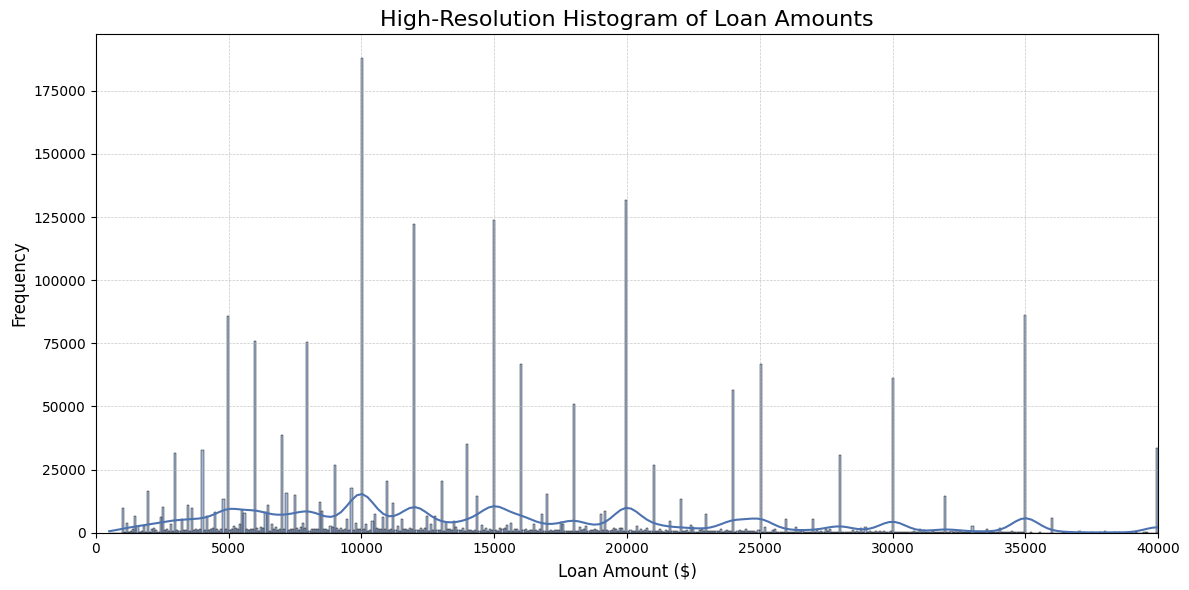

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df['loan_amnt'], bins=500, kde=True, color="#4C72B0", edgecolor="black", linewidth=0.3)
plt.title('High-Resolution Histogram of Loan Amounts', fontsize=16)
plt.xlabel('Loan Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 40000)  # LendingClub loans rarely go above $40k
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   loan_amnt           1345310 non-null  float64
 1   int_rate            1345310 non-null  float64
 2   sub_grade           1345310 non-null  object 
 3   emp_title           1259525 non-null  object 
 4   home_ownership      1345310 non-null  object 
 5   annual_inc          1345310 non-null  float64
 6   purpose             1345310 non-null  object 
 7   addr_state          1345310 non-null  object 
 8   dti                 1344936 non-null  float64
 9   revol_util          1344453 non-null  float64
 10  loan_repaid         1345310 non-null  int64  
 11  fico_mid            1345310 non-null  float64
 12  term_months         1345310 non-null  float64
 13  issue_months_since  1345310 non-null  float64
dtypes: float64(8), int64(1), object(5)
memory usage: 143.7+ MB


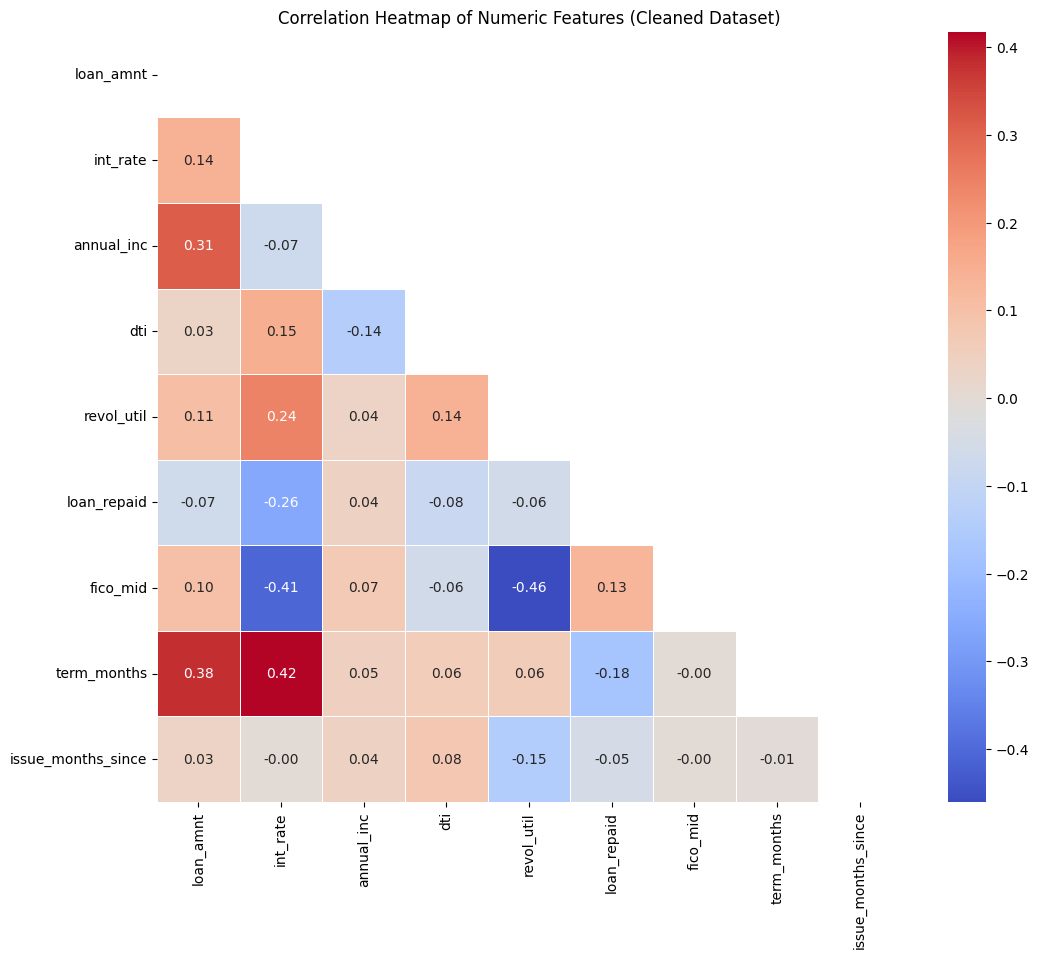

In [14]:
# Selecting only numeric columns from the cleaned modeling dataset
numeric_df = df_model.select_dtypes(include=['float64', 'int64'])

# Compute correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features (Cleaned Dataset)')
plt.show()


## One-Hot Encoding Categorical Variables

We now convert our four remaining categorical variables into one-hot encoded (dummy) variables so the model can use them directly. We keep all dummy columns (no `drop_first`) to preserve full information.

**Categorical columns encoded:**
- `sub_grade` — LendingClub’s combined grade/subgrade (A1–G5)
- `home_ownership` — Borrower’s housing status
- `purpose` — Loan purpose category
- `addr_state` — Borrower’s state of residence


In [15]:
# Inspect unique categories before one-hot encoding
for col in ['sub_grade', 'purpose', 'home_ownership', "addr_state"]:
    uniques = df_model[col].dropna().unique()
    print(f"\n{col} ({len(uniques)} unique values):")
    print(sorted(uniques) if len(uniques) < 50 else sorted(uniques)[:50])



sub_grade (35 unique values):
['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']

purpose (14 unique values):
['car', 'credit_card', 'debt_consolidation', 'educational', 'home_improvement', 'house', 'major_purchase', 'medical', 'moving', 'other', 'renewable_energy', 'small_business', 'vacation', 'wedding']

home_ownership (6 unique values):
['ANY', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']

addr_state (51 unique values):
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV']


In [16]:
# Columns to encode
categorical_cols = ['sub_grade', 'home_ownership', 'purpose', 'addr_state']

# One-hot encode without dropping first category
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

print("Original shape:", df_model.shape)
print("Encoded shape:", df_encoded.shape)
df_encoded.head()


Original shape: (1345310, 14)
Encoded shape: (1345310, 116)


,loan_amnt,int_rate,emp_title,annual_inc,dti,revol_util,loan_repaid,fico_mid,term_months,issue_months_since,...,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
0,3600.0,13.99,leadman,55000.0,5.91,29.7,1,677.0,36.0,102.0,...,False,False,False,False,False,False,False,False,False,False
1,24700.0,11.99,Engineer,65000.0,16.06,19.2,1,717.0,36.0,102.0,...,True,False,False,False,False,False,False,False,False,False
2,20000.0,10.78,truck driver,63000.0,10.78,56.2,1,697.0,60.0,102.0,...,False,False,False,False,False,False,False,False,False,False
3,10400.0,22.45,Contract Specialist,104433.0,25.37,64.5,1,697.0,60.0,102.0,...,False,False,False,False,False,False,False,False,False,False
4,11950.0,13.44,Veterinary Tecnician,34000.0,10.20,68.4,1,692.0,36.0,102.0,...,False,False,False,False,False,False,False,False,False,False


## Normalizing Job Titles for OpenAI Feature Engineering

Before sending the free-text job titles (`emp_title`) to OpenAI for categorization, we normalize them to reduce noise:

- Convert to lowercase
- Strip leading/trailing whitespace
- Remove punctuation and multiple spaces
- Replace blank or missing entries with `"unknown"`

This helps OpenAI receive cleaner, more consistent text for categorization and lowers API costs.


In [17]:
import re

if "emp_title" in df_model.columns:
    # Lowercase and strip whitespace
    df_model["emp_title_clean"] = df_model["emp_title"].astype(str).str.lower().str.strip()

    # Remove punctuation and collapse multiple spaces
    df_model["emp_title_clean"] = (
        df_model["emp_title_clean"]
        .apply(lambda x: re.sub(r"[^a-z0-9\s]", "", x))
        .str.replace(r"\s+", " ", regex=True)
    )

    # Replace empty or "nan" strings with "unknown" safely
    df_model["emp_title_clean"] = df_model["emp_title_clean"].replace({"": "unknown", "nan": "unknown"})

print(df_model[["emp_title", "emp_title_clean"]].head(10))


                                 emp_title  \
0                                  leadman   
1                                 Engineer   
2                             truck driver   
3                      Contract Specialist   
4                     Veterinary Tecnician   
5  Vice President of Recruiting Operations   
6                              road driver   
7                          SERVICE MANAGER   
8                           Vendor liaison   
9                        Logistics Manager   

                           emp_title_clean  
0                                  leadman  
1                                 engineer  
2                             truck driver  
3                      contract specialist  
4                     veterinary tecnician  
5  vice president of recruiting operations  
6                              road driver  
7                          service manager  
8                           vendor liaison  
9                        logistics manager 

In [18]:
unique_titles = df_model["emp_title_clean"].nunique(dropna=True)
print(f"Unique cleaned job titles: {unique_titles:,}")
print(df_model["emp_title_clean"].value_counts().head(20))


Unique cleaned job titles: 298,796
emp_title_clean
unknown               85786
teacher               26734
manager               26232
owner                 16172
registered nurse      12993
supervisor            12717
driver                12112
sales                 11178
rn                    10017
project manager        7913
office manager         7855
general manager        7445
truck driver           6791
director               5871
engineer               5316
president              5260
sales manager          4885
operations manager     4578
police officer         4560
vice president         4453
Name: count, dtype: int64


In [19]:
import re
import pandas as pd

def apply_title_aliases(s: pd.Series) -> pd.Series:
    x = s.fillna("").astype(str).str.lower().str.strip()
    x = x.str.replace(r"[^\w\s/+-]", " ", regex=True).str.replace(r"\s+", " ", regex=True)
    replacements = {
        r"\bvp\b": "vice president",
        r"\bsvp\b": "senior vice president",
        r"\bevps?\b": "executive vice president",
        r"\bavp\b": "assistant vice president",
        r"\bdir\b": "director",
        r"\bmgr\b": "manager",
        r"\bowner-?operator\b": "owner",
        r"\bself[- ]?employed\b": "owner",
        r"\bceo\b": "chief executive officer",
        r"\bcfo\b": "chief financial officer",
        r"\bcoo\b": "chief operating officer",
        r"\bcto\b": "chief technology officer",
        r"\bcio\b": "chief information officer",
        r"\brn\b": "registered nurse",
        r"\blpn\b": "licensed practical nurse",
        r"\blvn\b": "licensed vocational nurse",
        r"\bcna\b": "certified nursing assistant",
        r"\bpa\b": "physician assistant",
        r"\bemt\b": "emergency medical technician",
        r"\bpolice\b": "police officer",
        r"\btruck ?driver\b": "truck driver",
        r"\bcdl\b": "commercial driver",
        r"\bsys ?admin(istrator)?\b": "it support",
        r"\bsales rep(resentative)?\b": "sales representative",
        r"\brealtor\b": "real estate agent",
        r"\bnot working\b": "unemployed",
        r"\bunemployed\b": "unemployed",
        r"\bretired\b": "retired",
        r"\bstudent\b": "student",
    }
    for pat, repl in replacements.items():
        x = x.str.replace(pat, repl, regex=True)
    x = x.str.replace(r"\b(sr|jr|ii|iii|iv|v)\b", "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
    x = x.replace({"": "unknown", "none": "unknown", "n/a": "unknown"})
    return x

assert "emp_title_clean" in df_model.columns, "Run the title cleaning cell first."
df_model["emp_title_norm"] = apply_title_aliases(df_model["emp_title_clean"])
print("Unique titles after aliasing:", df_model["emp_title_norm"].nunique())


Unique titles after aliasing: 289598


## Classifying *All* Job Titles with GPT (40 Categories)

We classify every unique normalized job title (`emp_title_norm`) into one of 40 fixed categories using an LLM.  
To keep this repeatable and affordable, we:
- Cache mappings in `data/cache/job_title_to_category_mapping.csv` (so re-runs only classify new titles).
- Batch requests (tunable `BATCH_SIZE`) with exponential backoff on errors.
- Enforce strict JSON output and validate categories.
- Merge the final category back onto our dataset as `job_category_40`.

> Note: This run intentionally includes the long tail of rare titles.


In [ ]:
import os, json, re, math
import numpy as np
import pandas as pd
from tqdm import tqdm
import backoff
from openai import OpenAI

# ── Inputs ─────────────────────────────────────────────────────────
# df_model must already exist and contain 'emp_title_norm'
assert "emp_title_norm" in df_model.columns, "Run title normalization to create emp_title_norm first."

CATEGORIES = [
  "Executive Management","Functional Management","Frontline Supervisor","Self-Employed / Owner",
  "Software / Data / Eng","IT Support / SysAdmin",
  "Healthcare Practitioner","Healthcare Support",
  "Accounting / Finance","Banking / Lending","Insurance","Real Estate",
  "Retail Sales","B2B Sales / Account Mgmt","Marketing / PR","Customer Support",
  "Education","Public Administration",
  "Research / Science","Manufacturing / QA","Architecture / Civil / Mech Eng",
  "Licensed Trades","Construction Labor",
  "Commercial Driving","Delivery / Courier","Aviation",
  "Law Enforcement","Fire / Rescue","Military Enlisted (E1–E4)","Military NCO (E5–E9)","Military Officer",
  "Food Service / Hospitality","Personal Services","Creative / Media","Administration / Clerical",
  "Maintenance / Repair","Agriculture","Extraction / Mining",
  "Not Working / Unemployed","Training / Student",
  "Other"
]

MODEL = "gpt-5-mini"          # your chosen model
BATCH_SIZE = 50               # safe default; increase if needed
JOB_CAT_VERSION = "llm_v1_2025-09-19"
CACHE_CSV = "data/cache/job_title_to_category_mapping.csv"

# Pricing (optional; adjust to your account)
PRICE_PER_M_INPUT   = 0.25    # $ / 1M input tokens
PRICE_PER_M_OUTPUT  = 2.00    # $ / 1M output tokens
def _cost_from_tokens(prompt_toks: int, completion_toks: int) -> float:
    return (prompt_toks / 1_000_000) * PRICE_PER_M_INPUT + (completion_toks / 1_000_000) * PRICE_PER_M_OUTPUT

# ── LLM prompts ────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You classify job titles into exactly ONE category from a fixed list.\n"
    "Rules:\n"
    "- Output ONLY valid JSON: {\"results\":[{\"title\":...,\"category\":...}, ...]}\n"
    "- The 'category' MUST exactly match one of the provided categories.\n"
    "- If a title does not fit clearly, assign 'Other'. No explanations."
)

def build_user_prompt(titles):
    categories_str = "\n".join(f"- {c}" for c in CATEGORIES)
    list_str = "\n".join(titles)
    return (
        "Classify the following job titles into exactly one of these categories (exact string match required):\n"
        f"{categories_str}\n\n"
        "Return ONLY JSON with shape: {\"results\":[{\"title\":...,\"category\":...}, ...]}\n\n"
        f"Titles (preserve order):\n{list_str}\n"
    )

# ── Cache helpers ──────────────────────────────────────────────────
def load_cache(cache_csv=CACHE_CSV):
    os.makedirs(os.path.dirname(cache_csv), exist_ok=True)
    if os.path.exists(cache_csv):
        m = pd.read_csv(cache_csv)
        need = ["emp_title_norm","job_category_40","job_cat_version"]
        for c in need:
            if c not in m.columns: m[c] = np.nan
        return m[need].drop_duplicates("emp_title_norm")
    return pd.DataFrame(columns=["emp_title_norm","job_category_40","job_cat_version"])

def append_cache(rows, cache_csv=CACHE_CSV):
    if not rows: return
    new_df = pd.DataFrame(rows)
    if os.path.exists(cache_csv):
        old = pd.read_csv(cache_csv)
        combined = pd.concat([old, new_df], ignore_index=True)
    else:
        combined = new_df
    combined = combined.drop_duplicates(subset=["emp_title_norm"], keep="last")
    combined.to_csv(cache_csv, index=False)

# ── Build worklist: classify EVERYTHING not in cache ───────────────
all_titles = sorted(set(df_model["emp_title_norm"].fillna("").astype(str)))
cache = load_cache()
done = set(cache["emp_title_norm"])
work = [t for t in all_titles if t not in done]

print(f"Unique titles total: {len(all_titles):,}")
print(f"Already cached:       {len(done):,}")
print(f"To classify now:      {len(work):,}")

# ── LLM client & call ──────────────────────────────────────────────
client = OpenAI()

@backoff.on_exception(backoff.expo, Exception, max_time=90)
def classify_batch(titles, model=MODEL):
    resp = client.chat.completions.create(
        model=model,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_user_prompt(titles)},
        ]
    )
    text = resp.choices[0].message.content
    try:
        data = json.loads(text)
    except Exception:
        # Fallback: if the model somehow returned non-JSON, default to Other
        data = {"results": [{"title": t, "category": "Other"} for t in titles]}

    # Try to read real usage
    pt = getattr(getattr(resp, "usage", None), "prompt_tokens", 0) or 0
    ct = getattr(getattr(resp, "usage", None), "completion_tokens", 0) or 0

    out = []
    results = data.get("results", [])
    # Ensure we preserve order/length
    for i, t in enumerate(titles):
        cat = "Other"
        if i < len(results):
            c = results[i].get("category", "Other")
            cat = c if c in CATEGORIES else "Other"
        out.append({
            "emp_title_norm": t,
            "job_category_40": cat,
            "job_cat_version": JOB_CAT_VERSION
        })
    return out, {"prompt_tokens": int(pt), "completion_tokens": int(ct),
                 "cost_usd": _cost_from_tokens(int(pt), int(ct))}

# ── Pilot + full run ───────────────────────────────────────────────
cum_prompt = 0
cum_comp   = 0
cum_cost   = 0.0

if work:
    # Pilot
    pilot = work[:BATCH_SIZE]
    pilot_rows, usage = classify_batch(pilot)
    append_cache(pilot_rows)
    cum_prompt += usage["prompt_tokens"]; cum_comp += usage["completion_tokens"]; cum_cost += usage["cost_usd"]
    print(f"Pilot: {len(pilot_rows)} titles | est cost so far: ${cum_cost:,.4f}")

    # Remaining
    remaining = work[BATCH_SIZE:]
    total_batches = math.ceil(len(remaining) / BATCH_SIZE)
    for bi in tqdm(range(total_batches), desc="Classifying all titles"):
        batch = remaining[bi*BATCH_SIZE : (bi+1)*BATCH_SIZE]
        rows, usage = classify_batch(batch)
        append_cache(rows)
        cum_prompt += usage["prompt_tokens"]
        cum_comp   += usage["completion_tokens"]
        cum_cost   += usage["cost_usd"]

        if (bi + 1) % 10 == 0 or (bi + 1) == total_batches:
            processed = len(pilot) + (bi + 1) * BATCH_SIZE
            print(f"[{bi+1}/{total_batches}] processed ≈{processed:,} | "
                  f"prompt={cum_prompt:,}, completion={cum_comp:,} | "
                  f"est cost=${cum_cost:,.2f}")

else:
    print("Nothing new to classify — cache already covers all current titles.")

# ── Merge mapping into df_model (and df_encoded if present) ────────
mapping = load_cache()[["emp_title_norm","job_category_40","job_cat_version"]]
df_model = df_model.merge(mapping, on="emp_title_norm", how="left")

try:
    # If you already created df_encoded earlier, add the category too
    if 'df_encoded' in globals():
        df_encoded = df_encoded.merge(
            mapping, on="emp_title_norm", how="left"
        )
        # One-hot encode the new category if desired
        df_encoded = pd.get_dummies(df_encoded, columns=["job_category_40"], drop_first=False)
except Exception as e:
    print("Note: df_encoded not found or merge failed — this is fine if you haven't one-hot encoded yet.")
    print(repr(e))

print("\nMerge complete.")
print("Category coverage (df_model):", df_model["job_category_40"].notna().mean())
print("Sample categories:\n", df_model["job_category_40"].value_counts(dropna=False).head(10))
print(f"\nEstimated total cost: ${cum_cost:,.2f} (prompt={cum_prompt:,}, completion={cum_comp:,})")


In [96]:
# assumes df_model has emp_title_norm
titles = sorted(set(df_model["emp_title_norm"].fillna("").astype(str)))
np.save("data/cache/all_titles.npy", np.array(titles, dtype=object))
print(f"Saved {len(titles):,} titles to data/cache/all_titles.npy")


Saved 289,598 titles to data/cache/all_titles.npy


In [3]:
import os
import pandas as pd

# --- Adjust ONLY this if your project root ever moves ---
PROJECT_ROOT = "/Users/calebtelander/Python projects/Lendingclub-ml"
MAPPING_CSV  = os.path.join(PROJECT_ROOT, "data/cache/job_title_to_category_mapping.csv")

print("Reading mapping from:", MAPPING_CSV)
mapping = pd.read_csv(MAPPING_CSV)
req = {"emp_title_norm","job_category_40"}
assert req.issubset(mapping.columns), f"Mapping missing required columns: {req - set(mapping.columns)}"
print("Mapping rows:", len(mapping))

Reading mapping from: /Users/calebtelander/Python projects/Lendingclub-ml/data/cache/job_title_to_category_mapping.csv
Mapping rows: 289598


In [20]:
import re
import numpy as np

# If your active notebook has `df_model` already, use that; otherwise start from `df`
base_df = df_model if 'df_model' in globals() else df

# Create normalization if missing
if "emp_title_norm" not in base_df.columns:
    def normalize_title(title):
        if pd.isna(title): return ""
        t = str(title).lower().strip()
        t = re.sub(r"[^\w\s]", "", t)
        t = re.sub(r"\s+", " ", t)
        return t
    base_df = base_df.copy()
    base_df["emp_title_norm"] = base_df["emp_title"].apply(normalize_title)

print("Rows in base_df:", len(base_df))
print("Null emp_title_norm %:", base_df["emp_title_norm"].eq("").mean()*100)

Rows in base_df: 1345310
Null emp_title_norm %: 0.0


In [21]:
df_model = base_df.merge(
    mapping[["emp_title_norm","job_category_40"]],
    on="emp_title_norm",
    how="left"
)

miss_pct = df_model["job_category_40"].isna().mean()*100
print(f"After merge, missing job_category_40: {miss_pct:.2f}%")

# If you opted for Option A earlier, this should be ~0%. If not, you can fill:
df_model["job_category_40"] = df_model["job_category_40"].fillna("Other")

After merge, missing job_category_40: 0.00%


In [22]:
# Save a safety copy (optional)
df_with_titles = df_model.copy()

# Drop raw title fields for the modeling set
cols_to_drop = [c for c in ["emp_title", "emp_title_norm"] if c in df_model.columns]
df_model = df_model.drop(columns=cols_to_drop)
print("Dropped:", cols_to_drop)
print("df_model columns:", df_model.columns.tolist())

Dropped: ['emp_title', 'emp_title_norm']
df_model columns: ['loan_amnt', 'int_rate', 'sub_grade', 'home_ownership', 'annual_inc', 'purpose', 'addr_state', 'dti', 'revol_util', 'loan_repaid', 'fico_mid', 'term_months', 'issue_months_since', 'emp_title_clean', 'job_category_40']


In [23]:
# Create a processed folder if not present
processed_dir = os.path.join(PROJECT_ROOT, "data/processed")
os.makedirs(processed_dir, exist_ok=True)

out_parquet = os.path.join(processed_dir, "df_model_ready.parquet")
out_sample  = os.path.join(processed_dir, "df_model_ready_sample.csv")

df_model.to_parquet(out_parquet, index=False)
df_model.sample(n=min(5000, len(df_model)), random_state=42).to_csv(out_sample, index=False)

print("Saved:")
print(" -", out_parquet)
print(" -", out_sample)

Saved:
 - /Users/calebtelander/Python projects/Lendingclub-ml/data/processed/df_model_ready.parquet
 - /Users/calebtelander/Python projects/Lendingclub-ml/data/processed/df_model_ready_sample.csv


In [24]:
print(df_model["job_category_40"].value_counts().head(15))
print("Shape:", df_model.shape)

job_category_40
Other                        239047
Functional Management        169426
Healthcare Practitioner       80098
Education                     72070
Administration / Clerical     71186
Frontline Supervisor          58481
Software / Data / Eng         57557
Accounting / Finance          53459
B2B Sales / Account Mgmt      52908
Manufacturing / QA            51778
Maintenance / Repair          36862
Self-Employed / Owner         32677
Public Administration         32339
Commercial Driving            29163
Law Enforcement               27449
Name: count, dtype: int64
Shape: (1345310, 15)


In [26]:
# --- Drop emp_title_clean (we have job_category_40 instead) ---
df_model = df_model.drop(columns=['emp_title_clean'])

# --- Choose categorical columns to encode ---
categorical_cols = ['sub_grade', 'home_ownership', 'purpose', 'addr_state', 'job_category_40']

# --- One-hot encode (no drop_first so you keep full set of dummies) ---
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

print("Encoded shape:", df_encoded.shape)
print("Columns now:", df_encoded.columns[:15], "...")  # preview first few

Encoded shape: (1345310, 156)
Columns now: Index(['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util',
       'loan_repaid', 'fico_mid', 'term_months', 'issue_months_since',
       'sub_grade_A1', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4',
       'sub_grade_A5', 'sub_grade_B1'],
      dtype='object') ...


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['loan_repaid'])
y = df_encoded['loan_repaid']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numeric columns for scaling
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Positive class rate (train):", y_train.mean())

Train shape: (1076248, 155)
Test shape : (269062, 155)
Positive class rate (train): 0.8003740773502018


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Optional: force CPU instead of Metal GPU
# tf.config.set_visible_devices([], 'GPU')  # uncomment to use CPU only

# Optional: mixed precision on M2 for faster training
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("mixed_float16")

input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', dtype='float32')  # ensure float32 output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=1024,
    verbose=1
)

Epoch 1/5
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.1991 - auc: 0.5000 - loss: nan - val_accuracy: 0.1984 - val_auc: 0.5000 - val_loss: nan
Epoch 2/5
841/841 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2000 - auc: 0.5000 - loss: nan - val_accuracy: 0.1984 - val_auc: 0.5000 - val_loss: nan
Epoch 3/5
841/841 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2002 - auc: 0.5000 - loss: nan - val_accuracy: 0.1984 - val_auc: 0.5000 - val_loss: nan
Epoch 4/5
841/841 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1996 - auc: 0.5000 - loss: nan - val_accuracy: 0.1984 - val_auc: 0.5000 - val_loss: nan
Epoch 5/5
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.2003 - auc: 0.5000 - loss: nan - val_accuracy: 0.1984 - val_auc: 0.5000 - val_loss: nan


In [35]:
import numpy as np
import pandas as pd

def list_non_numeric(df):
    non_num = df.columns[~df.dtypes.apply(lambda dt: np.issubdtype(dt, np.number))]
    return pd.DataFrame({"column": non_num, "dtype": df[non_num].dtypes.astype(str)})

print("X_train dtypes summary:")
print(X_train.dtypes.value_counts(), "\n")

print("Non-numeric columns in X_train:")
display(list_non_numeric(X_train))

X_train dtypes summary:
bool       147
float64      8
Name: count, dtype: int64 

Non-numeric columns in X_train:


,column,dtype
sub_grade_A1,sub_grade_A1,bool
sub_grade_A2,sub_grade_A2,bool
sub_grade_A3,sub_grade_A3,bool
sub_grade_A4,sub_grade_A4,bool
sub_grade_A5,sub_grade_A5,bool
...,...,...
job_category_40_Research / Science,job_category_40_Research / Science,bool
job_category_40_Retail Sales,job_category_40_Retail Sales,bool
job_category_40_Self-Employed / Owner,job_category_40_Self-Employed / Owner,bool
job_category_40_Software / Data / Eng,job_category_40_Software / Data / Eng,bool


In [36]:
# --- Booleans to uint8 ---
bool_cols_train = X_train.select_dtypes(include=['bool']).columns
bool_cols_test  = X_test.select_dtypes(include=['bool']).columns
X_train[bool_cols_train] = X_train[bool_cols_train].astype('uint8')
X_test[bool_cols_test]   = X_test[bool_cols_test].astype('uint8')

# --- Residual object columns? One-hot them jointly so columns match ---
obj_cols = X_train.select_dtypes(include=['object']).columns
if len(obj_cols) > 0:
    combined = pd.concat([X_train, X_test], axis=0)
    combined = pd.get_dummies(combined, columns=list(obj_cols), drop_first=False, dtype=np.uint8)
    # split back
    X_train = combined.iloc[:len(X_train)].copy()
    X_test  = combined.iloc[len(X_train):].copy()

In [37]:
def check_numeric_integrity(X, name):
    num = X.select_dtypes(include=[np.number])
    n_nan = np.isnan(num.values).sum()
    n_inf = np.isinf(num.values).sum()
    print(f"{name}: numeric_cols={num.shape[1]} | NaNs={n_nan:,} | Infs={n_inf:,}")

check_numeric_integrity(X_train, "X_train")
check_numeric_integrity(X_test,  "X_test")

X_train: numeric_cols=155 | NaNs=0 | Infs=0
X_test: numeric_cols=155 | NaNs=0 | Infs=0


In [39]:
print("y dtype:", y_train.dtype)
print("y unique (first 20):", pd.Series(y_train).unique()[:20])
print("y value_counts:\n", pd.Series(y_train).value_counts(dropna=False).head(10))
print("y NaNs:", pd.Series(y_train).isna().sum())

y dtype: int64
y unique (first 20): [1 0]
y value_counts:
 loan_repaid
1    861401
0    214847
Name: count, dtype: int64
y NaNs: 0


In [41]:
import numpy as np
X_train, X_test = X_train.astype("float32"), X_test.astype("float32")
y_train, y_test = y_train.astype("float32"), y_test.astype("float32")

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', dtype='float32')
])

opt = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)  # gradient clipping

model.compile(
    optimizer=opt,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [43]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=3,           # quick check; increase after it’s stable
    batch_size=1024,
    verbose=1
)

Epoch 1/3
841/841 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7818 - auc: 0.6614 - loss: 0.4904 - val_accuracy: 0.8032 - val_auc: 0.7119 - val_loss: 0.4530
Epoch 2/3
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7991 - auc: 0.6998 - loss: 0.4614 - val_accuracy: 0.8035 - val_auc: 0.7124 - val_loss: 0.4529
Epoch 3/3
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8005 - auc: 0.7038 - loss: 0.4587 - val_accuracy: 0.8033 - val_auc: 0.7130 - val_loss: 0.4528


In [44]:
loss, acc, auc = model.evaluate(X_test.astype("float32"), y_test.astype("float32"), verbose=1)
print(f"Test — loss: {loss:.4f} | acc: {acc:.4f} | AUC: {auc:.4f}")

8409/8409 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8010 - auc: 0.7126 - loss: 0.4552
Test — loss: 0.4542 | acc: 0.8017 | AUC: 0.7134


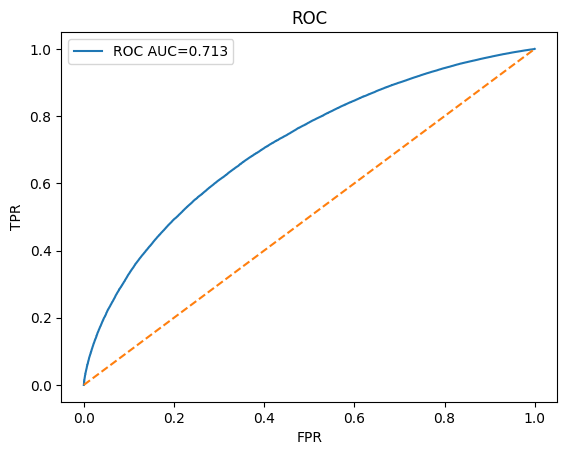

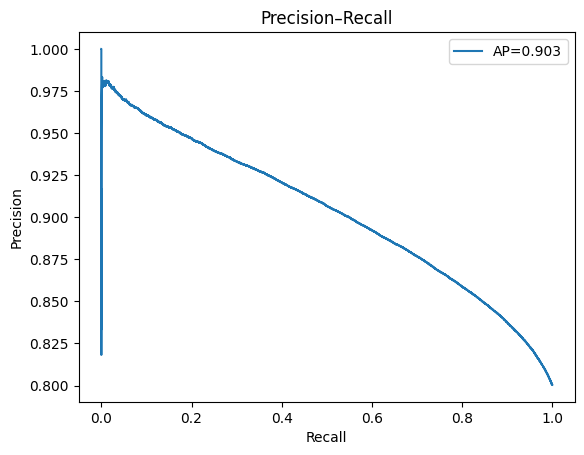

In [45]:
from sklearn.metrics import roc_curve, auc as sk_auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

proba = model.predict(X_test.astype("float32"), verbose=0).ravel()

# ROC
fpr, tpr, thr = roc_curve(y_test, proba)
roc_auc = sk_auc(fpr, tpr)
plt.figure(); plt.plot(fpr, tpr, label=f'ROC AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC'); plt.show()

# PR
prec, rec, thr_pr = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
plt.figure(); plt.plot(rec, prec, label=f'AP={ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(); plt.title('Precision–Recall'); plt.show()

In [46]:
# maximize Youden’s J (tpr - fpr)
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thr[best_idx]
print(f"Best threshold (Youden J): {best_thr:.3f}")

from sklearn.metrics import classification_report, confusion_matrix
y_pred = (proba >= best_thr).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Best threshold (Youden J): 0.787
[[ 35095  18617]
 [ 73851 141499]]
              precision    recall  f1-score   support

         0.0      0.322     0.653     0.432     53712
         1.0      0.884     0.657     0.754    215350

    accuracy                          0.656    269062
   macro avg      0.603     0.655     0.593    269062
weighted avg      0.772     0.656     0.689    269062



In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early = EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)
plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)

history = model.fit(
    X_train.astype("float32"), y_train.astype("float32"),
    validation_split=0.2,
    epochs=40,
    batch_size=1024,
    callbacks=[early, plateau],
    verbose=1
)

Epoch 1/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8005 - auc: 0.7056 - loss: 0.4581 - val_accuracy: 0.8034 - val_auc: 0.7133 - val_loss: 0.4526 - learning_rate: 0.0010
Epoch 2/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7997 - auc: 0.7075 - loss: 0.4585 - val_accuracy: 0.8029 - val_auc: 0.7133 - val_loss: 0.4533 - learning_rate: 0.0010
Epoch 3/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8007 - auc: 0.7090 - loss: 0.4570 - val_accuracy: 0.8037 - val_auc: 0.7128 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 4/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8003 - auc: 0.7093 - loss: 0.4569 - val_accuracy: 0.8028 - val_auc: 0.7136 - val_loss: 0.4530 - learning_rate: 5.0000e-04
Epoch 5/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8006 - auc: 0.7095 - loss: 0.4570 - val_accuracy: 0.8029 - val_auc: 0.7130 - val_loss: 0.4530 - learning_rate: 5.0000e-04
Epoch 6/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accura

In [48]:
# Suppose y_train has 0 for Charged Off and 1 for Fully Paid
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print(class_weight)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=1024,
    class_weight=class_weight,
    verbose=1
)

{0.0: 2.504684729132825, 1.0: 0.6247078886604497}
Epoch 1/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7432 - auc: 0.6791 - loss: 0.7112 - val_accuracy: 0.6977 - val_auc: 0.7007 - val_loss: 0.5837
Epoch 2/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6866 - auc: 0.6927 - loss: 0.6451 - val_accuracy: 0.6788 - val_auc: 0.7058 - val_loss: 0.5983
Epoch 3/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6766 - auc: 0.6968 - loss: 0.6398 - val_accuracy: 0.6764 - val_auc: 0.7093 - val_loss: 0.5972
Epoch 4/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6715 - auc: 0.7007 - loss: 0.6345 - val_accuracy: 0.6665 - val_auc: 0.7109 - val_loss: 0.6042
Epoch 5/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6677 - auc: 0.7023 - loss: 0.6320 - val_accuracy: 0.6546 - val_auc: 0.7116 - val_loss: 0.6139
Epoch 6/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6632 - auc: 0.7027 - loss: 0.6299 - val_accuracy: 0.6597 - v

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

logit = LogisticRegression(max_iter=1000, n_jobs=-1)
logit.fit(X_train, y_train)
proba_lr = logit.predict_proba(X_test)[:,1]
print("Baseline LR AUC:", roc_auc_score(y_test, proba_lr))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Baseline LR AUC: 0.7152328199295104


In [50]:
import os, json, datetime
RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
MODEL_DIR = f"models/run_{RUN_ID}"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Saving to", MODEL_DIR)

Saving to models/run_20250923-163936


In [51]:
model.save(f"{MODEL_DIR}/model.keras")        # preferred TF/Keras format
# Optional extra: lightweight SavedModel for TF Serving
# model.save(f"{MODEL_DIR}/saved_model", save_format="tf")

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions as probabilities
y_pred_proba = model.predict(X_test).ravel()
# Pick a default threshold of 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_proba))

8409/8409 ━━━━━━━━━━━━━━━━━━━━ 8s 904us/step
              precision    recall  f1-score   support

         0.0       0.32      0.67      0.43     53712
         1.0       0.89      0.64      0.74    215350

    accuracy                           0.64    269062
   macro avg       0.60      0.66      0.59    269062
weighted avg       0.77      0.64      0.68    269062

[[ 36216  17496]
 [ 78364 136986]]
Test ROC AUC: 0.7135509117705664


In [54]:
# === Compare model WITHOUT job-title features ===
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1) Drop job-related columns from X
job_cols = [c for c in X_train.columns if c.startswith("job_category_40_")]
if "emp_title_clean" in X_train.columns:
    job_cols.append("emp_title_clean")

print(f"Dropping {len(job_cols)} job-related columns")
X_train_nojob = X_train.drop(columns=job_cols, errors="ignore")
X_test_nojob  = X_test.drop(columns=job_cols, errors="ignore")
print("Shapes -> with job:", X_train.shape, "| no job:", X_train_nojob.shape)

# 2) Build the same model architecture (wrap if not already in a function)
def build_model(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# 3) Class weights (recompute if not defined)
try:
    class_weight  # use existing if present
except NameError:
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight = dict(zip(classes, weights))

# 4) Train
model_nojob = build_model(X_train_nojob.shape[1])
history_nojob = model_nojob.fit(
    X_train_nojob, y_train,
    validation_data=(X_test_nojob, y_test),
    epochs=40,
    batch_size=1024,
    class_weight=class_weight,
    verbose=1
)

# 5) Evaluate
proba_nojob = model_nojob.predict(X_test_nojob, verbose=0).ravel()
auc_nojob   = roc_auc_score(y_test, proba_nojob)
pr_auc      = average_precision_score(y_test, proba_nojob)

# Choose a threshold (Youden J on ROC)
fpr, tpr, thr = roc_curve(y_test, proba_nojob)
best_thr = float(thr[(tpr - fpr).argmax()])
y_pred_05 = (proba_nojob >= 0.50).astype(int)
y_pred_bt = (proba_nojob >= best_thr).astype(int)

print(f"\nNO-JOB MODEL  |  ROC AUC={auc_nojob:.3f}  PR AUC={pr_auc:.3f}  best_thr={best_thr:.3f}")
print("\n@0.50 threshold")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05, digits=3))
print("\n@best-threshold (Youden J)")
print(confusion_matrix(y_test, y_pred_bt))
print(classification_report(y_test, y_pred_bt, digits=3))

Dropping 41 job-related columns
Shapes -> with job: (1076248, 155) | no job: (1076248, 114)
Epoch 1/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6287 - auc: 0.6800 - loss: 0.6477 - val_accuracy: 0.6385 - val_auc: 0.7102 - val_loss: 0.6299
Epoch 2/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6422 - auc: 0.7060 - loss: 0.6262 - val_accuracy: 0.6290 - val_auc: 0.7099 - val_loss: 0.6349
Epoch 3/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6393 - auc: 0.7062 - loss: 0.6262 - val_accuracy: 0.6406 - val_auc: 0.7108 - val_loss: 0.6255
Epoch 4/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6410 - auc: 0.7066 - loss: 0.6262 - val_accuracy: 0.6448 - val_auc: 0.7108 - val_loss: 0.6225
Epoch 5/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6402 - auc: 0.7053 - loss: 0.6276 - val_accuracy: 0.6364 - val_auc: 0.7110 - val_loss: 0.6277
Epoch 6/40
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6381 - auc: 0.7044